# Лабораторна робота № 2

## Оптимізаційна задача та аналіз чутливості

**Дисципліна:** Інтелектуальний аналіз та візуалізація даних (СК26)
**Тривалість:** 2 год аудиторно + 3 год самостійної роботи · **Максимальна оцінка:** 4 бали

---

### Мета роботи

Побудувати оптимізаційну модель у двох середовищах, прочитати звіт про стійкість
і **ухвалити на його основі господарське рішення**.

Розв'язати задачу — не мета. Solver зробить це за дві секунди. Робота оцінюється за
те, що ви зумієте зі звіту витягнути.

### Дві частини

| Частина | Задача | Де виконується |
|---|---|---|
| **1** | виробнича задача — Excel і Python | аудиторно |
| **2** | транспортна задача — Python | самостійно |

Друга частина потрібна не для повторення. Там та сама методика поводиться інакше,
і ви маєте побачити, де саме проходить межа її застосовності.

### Що здається

1. Цей файл `.ipynb` із заповненими розв'язками. **Виконується згори донизу на чистому
   ядрі** (Kernel → Restart & Run All) без помилок — перевіряється першою дією на захисті.
2. Файл Excel з моделлю, налаштуваннями Solver і **звітом про стійкість** окремим аркушем.
3. Заповнена декларація про використання ШІ (етап 12).

### Оцінювання

| Бали | Що досягнуто |
|---|---|
| 0 | Модель не сформульовано або розв'язок не отримано |
| 1 | Розв'язок отримано лише в одному середовищі, звіт про стійкість не проаналізовано |
| 2 | Задачу розв'язано в обох середовищах і звіти зіставлено, але тіньові ціни та діапазони не інтерпретовано |
| 4 | Звіт прочитано й перевірено експериментом, ухвалено обґрунтоване рішення про закупівлю, виконано частину 2 з поясненням розбіжності |

---
## Крок 0. Ваші дані та варіант

In [1]:
ПІБ = 'Смачило Іванна Ростиславівна'        # напр. 'Шевченко Тарас'
ГРУПА = 'ШІ-33'      # напр. 'КН-31'
ВАРІАНТ = 11     # ваш номер за списком групи

assert ПІБ and ГРУПА and 1 <= ВАРІАНТ <= 30, 'Заповніть ПІБ, ГРУПУ та ВАРІАНТ (1..30)'

In [2]:
# --- клітинку не редагувати: вона видає дані вашого варіанта -----------------
import json, numpy as np, pandas as pd

ДАНІ_ВАРІАНТІВ = json.loads('''{"1": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[0, 2, 1, 1], [3, 3, 0, 6], [2, 3, 0, 2], [4, 6, 0, 5], [3, 1, 5, 4]], "c": [21, 69, 44, 39], "b": [929, 410, 507, 865, 425], "ресурс_пропозиції": 1, "ціна_пропозиції": 16.2, "обсяг_пропозиції": 44}, "2": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[4, 2, 5, 2], [6, 5, 4, 2], [5, 2, 0, 3], [2, 1, 5, 0], [5, 5, 6, 2]], "c": [40, 66, 24, 34], "b": [1271, 702, 915, 1388, 804], "ресурс_пропозиції": 1, "ціна_пропозиції": 16.7, "обсяг_пропозиції": 204}, "3": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[5, 2, 6, 6], [3, 4, 3, 6], [1, 6, 6, 0], [3, 1, 6, 1], [4, 1, 1, 4]], "c": [51, 16, 34, 22], "b": [1189, 686, 1311, 512, 1030], "ресурс_пропозиції": 3, "ціна_пропозиції": 11.3, "обсяг_пропозиції": 348}, "4": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[5, 0, 0, 0], [1, 0, 5, 2], [2, 4, 6, 5], [3, 0, 5, 3], [2, 1, 2, 5]], "c": [41, 50, 54, 26], "b": [815, 344, 840, 840, 382], "ресурс_пропозиції": 4, "ціна_пропозиції": 8.3, "обсяг_пропозиції": 144}, "5": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[3, 0, 6, 6], [3, 2, 2, 4], [5, 5, 0, 6], [2, 1, 5, 3], [5, 5, 4, 2]], "c": [32, 66, 25, 24], "b": [874, 1034, 1349, 845, 1394], "ресурс_пропозиції": 2, "ціна_пропозиції": 8.6, "обсяг_пропозиції": 90}, "6": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[3, 2, 1, 4], [4, 2, 2, 1], [3, 5, 1, 2], [3, 2, 0, 2], [6, 4, 6, 3]], "c": [40, 62, 19, 57], "b": [630, 391, 1349, 811, 1085], "ресурс_пропозиції": 1, "ціна_пропозиції": 29.5, "обсяг_пропозиції": 268}, "7": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[0, 0, 5, 5], [4, 4, 0, 1], [2, 4, 0, 6], [6, 3, 4, 1], [2, 2, 1, 0]], "c": [20, 59, 63, 41], "b": [1189, 1189, 1217, 915, 424], "ресурс_пропозиції": 3, "ціна_пропозиції": 8.0, "обсяг_пропозиції": 314}, "8": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[2, 1, 3, 5], [3, 1, 0, 6], [1, 6, 1, 5], [2, 2, 4, 0], [6, 1, 2, 2]], "c": [60, 25, 59, 25], "b": [1279, 761, 376, 1230, 1065], "ресурс_пропозиції": 3, "ціна_пропозиції": 9.5, "обсяг_пропозиції": 234}, "9": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[5, 2, 1, 2], [5, 0, 1, 3], [5, 4, 6, 4], [4, 1, 1, 5], [6, 0, 3, 0]], "c": [58, 39, 54, 16], "b": [1147, 1199, 1280, 404, 1170], "ресурс_пропозиції": 2, "ціна_пропозиції": 6.1, "обсяг_пропозиції": 672}, "10": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[4, 0, 4, 3], [0, 6, 0, 6], [5, 5, 3, 5], [6, 2, 3, 3], [3, 0, 0, 4]], "c": [20, 29, 37, 63], "b": [905, 344, 866, 1390, 355], "ресурс_пропозиції": 0, "ціна_пропозиції": 5.3, "обсяг_пропозиції": 78}, "11": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[2, 1, 0, 3], [3, 1, 4, 0], [1, 0, 3, 2], [3, 2, 2, 6], [3, 6, 0, 3]], "c": [30, 16, 51, 35], "b": [1312, 838, 1062, 1038, 1236], "ресурс_пропозиції": 1, "ціна_пропозиції": 15.6, "обсяг_пропозиції": 778}, "12": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[5, 2, 0, 5], [1, 1, 3, 6], [6, 3, 5, 4], [2, 4, 6, 0], [4, 6, 2, 4]], "c": [39, 55, 36, 26], "b": [788, 661, 458, 1005, 535], "ресурс_пропозиції": 4, "ціна_пропозиції": 5.0, "обсяг_пропозиції": 762}, "13": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[1, 5, 3, 0], [6, 4, 6, 3], [4, 4, 4, 1], [0, 3, 5, 3], [3, 5, 3, 3]], "c": [59, 42, 53, 19], "b": [937, 1390, 603, 1120, 1334], "ресурс_пропозиції": 2, "ціна_пропозиції": 15.1, "обсяг_пропозиції": 646}, "14": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[4, 3, 3, 4], [6, 6, 1, 6], [1, 3, 5, 1], [1, 5, 1, 4], [4, 4, 0, 3]], "c": [26, 56, 41, 40], "b": [969, 672, 1364, 878, 618], "ресурс_пропозиції": 2, "ціна_пропозиції": 5.0, "обсяг_пропозиції": 222}, "15": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[5, 3, 3, 1], [2, 5, 6, 6], [3, 1, 0, 0], [0, 4, 4, 6], [2, 2, 2, 6]], "c": [64, 58, 34, 63], "b": [613, 316, 1035, 739, 810], "ресурс_пропозиції": 0, "ціна_пропозиції": 5.4, "обсяг_пропозиції": 354}, "16": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[1, 6, 4, 2], [4, 1, 1, 2], [4, 4, 6, 6], [5, 6, 3, 3], [1, 2, 4, 2]], "c": [33, 40, 58, 17], "b": [412, 1005, 996, 599, 390], "ресурс_пропозиції": 4, "ціна_пропозиції": 8.2, "обсяг_пропозиції": 44}, "17": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[2, 6, 0, 3], [2, 5, 5, 3], [6, 0, 4, 5], [1, 3, 6, 2], [0, 1, 4, 4]], "c": [33, 52, 20, 66], "b": [989, 1079, 873, 1327, 1224], "ресурс_пропозиції": 0, "ціна_пропозиції": 5.9, "обсяг_пропозиції": 402}, "18": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[2, 3, 0, 1], [0, 6, 1, 6], [1, 0, 4, 1], [2, 6, 3, 4], [3, 1, 6, 5]], "c": [66, 54, 18, 66], "b": [1217, 668, 923, 1040, 619], "ресурс_пропозиції": 4, "ціна_пропозиції": 34.9, "обсяг_пропозиції": 100}, "19": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[2, 1, 0, 2], [3, 3, 4, 5], [2, 1, 0, 4], [4, 1, 5, 0], [0, 3, 6, 3]], "c": [67, 52, 41, 40], "b": [315, 617, 815, 423, 1193], "ресурс_пропозиції": 1, "ціна_пропозиції": 9.3, "обсяг_пропозиції": 332}, "20": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[5, 4, 5, 1], [2, 0, 5, 4], [4, 0, 2, 3], [3, 3, 4, 3], [4, 4, 5, 2]], "c": [42, 63, 35, 56], "b": [1191, 331, 685, 1275, 971], "ресурс_пропозиції": 4, "ціна_пропозиції": 12.2, "обсяг_пропозиції": 604}, "21": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[5, 5, 3, 6], [4, 4, 3, 2], [4, 4, 4, 0], [1, 1, 5, 3], [0, 2, 6, 5]], "c": [32, 66, 26, 64], "b": [464, 393, 354, 597, 887], "ресурс_пропозиції": 0, "ціна_пропозиції": 9.4, "обсяг_пропозиції": 190}, "22": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[6, 0, 2, 6], [3, 4, 0, 4], [4, 3, 1, 5], [5, 5, 6, 2], [2, 0, 1, 5]], "c": [65, 36, 50, 63], "b": [891, 1247, 613, 1070, 1259], "ресурс_пропозиції": 2, "ціна_пропозиції": 13.6, "обсяг_пропозиції": 64}, "23": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[1, 2, 4, 6], [4, 6, 2, 5], [0, 5, 3, 1], [0, 0, 5, 1], [5, 4, 0, 5]], "c": [15, 35, 49, 23], "b": [1251, 637, 304, 629, 923], "ресурс_пропозиції": 2, "ціна_пропозиції": 10.9, "обсяг_пропозиції": 146}, "24": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[3, 2, 6, 1], [0, 2, 5, 6], [2, 4, 4, 0], [5, 6, 2, 5], [2, 4, 2, 1]], "c": [45, 61, 59, 38], "b": [927, 1384, 1294, 798, 323], "ресурс_пропозиції": 4, "ціна_пропозиції": 20.5, "обсяг_пропозиції": 110}, "25": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[5, 5, 4, 4], [2, 1, 4, 1], [3, 1, 4, 4], [1, 4, 2, 0], [6, 4, 6, 6]], "c": [35, 27, 63, 61], "b": [1399, 843, 308, 1393, 713], "ресурс_пропозиції": 2, "ціна_пропозиції": 7.7, "обсяг_пропозиції": 334}, "26": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[4, 1, 4, 4], [3, 1, 5, 0], [6, 3, 6, 3], [1, 3, 6, 1], [6, 4, 5, 2]], "c": [46, 57, 60, 39], "b": [513, 1330, 796, 406, 1258], "ресурс_пропозиції": 3, "ціна_пропозиції": 18.1, "обсяг_пропозиції": 448}, "27": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[2, 1, 6, 0], [6, 5, 6, 0], [5, 2, 3, 0], [6, 4, 3, 6], [6, 0, 0, 3]], "c": [24, 61, 50, 57], "b": [1179, 1358, 417, 463, 610], "ресурс_пропозиції": 3, "ціна_пропозиції": 9.0, "обсяг_пропозиції": 742}, "28": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[4, 5, 6, 2], [6, 4, 2, 1], [0, 5, 4, 3], [6, 6, 3, 3], [4, 4, 4, 1]], "c": [37, 41, 30, 29], "b": [514, 461, 378, 834, 488], "ресурс_пропозиції": 2, "ціна_пропозиції": 5.5, "обсяг_пропозиції": 174}, "29": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[3, 5, 0, 5], [6, 0, 6, 1], [5, 2, 2, 3], [0, 3, 0, 1], [4, 5, 5, 0]], "c": [33, 57, 58, 62], "b": [820, 523, 670, 977, 1074], "ресурс_пропозиції": 0, "ціна_пропозиції": 15.2, "обсяг_пропозиції": 570}, "30": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[2, 1, 4, 0], [6, 5, 1, 4], [5, 6, 1, 4], [1, 2, 6, 0], [1, 0, 3, 1]], "c": [51, 44, 69, 55], "b": [379, 620, 1256, 502, 414], "ресурс_пропозиції": 1, "ціна_пропозиції": 16.9, "обсяг_пропозиції": 230}}''')

V = ДАНІ_ВАРІАНТІВ[str(ВАРІАНТ)]
A = np.array(V['A'], float)          # витрати ресурсу i на один виріб j
c = np.array(V['c'], float)          # прибуток з одного виробу
b = np.array(V['b'], float)          # запас ресурсу на плановий період
вироби, ресурси = V['вироби'], V['ресурси']

print('ВАРІАНТ %d · %s, %s, %s' % (ВАРІАНТ, ПІБ, ГРУПА, V['фірма']))
print('=' * 78)
print('Підприємство %s виготовляє %s. Одиниця виміру плану: %s.' % (V['фірма'], V['що'], V['од']))
print()
таб = pd.DataFrame(A, index=ресурси, columns=вироби).astype(int)
таб['ЗАПАС'] = b.astype(int)
print(таб.to_string())
print()
print(pd.DataFrame([c.astype(int)], index=['Прибуток з одиниці'], columns=вироби).to_string())
print()
print('ПРОПОЗИЦІЯ ПОСТАЧАЛЬНИКА (знадобиться на етапі 6)')
print('  ресурс: %s' % ресурси[V['ресурс_пропозиції']])
print('  ціна:   %.1f за одиницю' % V['ціна_пропозиції'])
print('  обсяг:  до %d одиниць' % V['обсяг_пропозиції'])

ВАРІАНТ 11 · Смачило Іванна Ростиславівна, ШІ-33, «Карпатський дуб»
Підприємство «Карпатський дуб» виготовляє меблі. Одиниця виміру плану: шт./тиждень.

                   Крісло  Стілець  Табурет  Лава  ЗАПАС
Дубовий брус, м         2        1        0     3   1312
Фанера, м²              3        1        4     0    838
Фурнітура, компл.       1        0        3     2   1062
Верстат, год            3        2        2     6   1038
Лакування, год          3        6        0     3   1236

                    Крісло  Стілець  Табурет  Лава
Прибуток з одиниці      30       16       51    35

ПРОПОЗИЦІЯ ПОСТАЧАЛЬНИКА (знадобиться на етапі 6)
  ресурс: Фанера, м²
  ціна:   15.6 за одиницю
  обсяг:  до 778 одиниць


In [5]:
import sys
!{sys.executable} -m pip install scipy pulp pandas matplotlib
import matplotlib.pyplot as plt
try:
    import pulp
    ПУЛП = True
except ImportError:
    ПУЛП = False
    print('pulp не встановлено — скористайтеся scipy.optimize.linprog')
from scipy.optimize import linprog

pd.set_option('display.width', 180)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 9})

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 30.3 MB 1.8 MB/s eta 0:00:01
     |████████████████████████████████| 16.4 MB 44.6 MB/s eta 0:00:01    |█████████████████▏              | 8.8 MB 44.6 MB/s eta 0:00:01
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


---
# ЧАСТИНА 1. Виробнича задача

# Етап 1. Формалізація

Перш ніж будувати таблицю, запишіть модель словами й формулами. Це найважливіші
двадцять хвилин роботи: помилку тут не виправить жодна кнопка.

### Завдання 1.1
Заповніть у клітинці нижче:

* **змінні рішення** — що саме ви обираєте і в яких одиницях;
* **цільова функція** — що робите найбільшим, з коефіцієнтами вашого варіанта;
* **обмеження** — по одному рядку на кожен ресурс, з числами вашого варіанта;
* **умови невід'ємності**.

Пишіть формулами, а не описом. Приклад запису одного обмеження:
`8·x1 + 4·x2 + 0·x3 + 2·x4 ≤ 1280   (конвеєр A)`

**Відповідь 1.1 — символічна модель**

Змінні рішення: x1, x2, x3, x4 ≥ 0

Цільова функція: Z = 30x1 + 16x2 + 51x3 + 35x4 -> max

Обмеження: 
2·x1 + 1·x2 + 0·x3 + 3·x4 ≤ 1312 (брус)
3·x1 + 1·x2 + 4x3 + 0·x4 ≤ 838 (фанера)
1·x1 + 0·x2 + 3·x3 + 2·x4 ≤ 1062 (фурнітура)
3·x1 + 2·x2 + 2·x3 + 6·x4 ≤ 1038 (верстат)
3·x1 + 6·x2 + 0·x3 + 3x4 ≤ 1236 (лакування)

Невід'ємність: x1, x2, x3, x4 ≥ 0


### Завдання 1.2 — питання на розуміння
Чому запас ресурсу — це **параметр**, а не змінна рішення? Що змінилося б у моделі,
якби підприємство могло докупити ресурс у будь-якій кількості?

**Відповідь 1.2:** Запаси ресурсів є параметрами, бо вони визначаються наявними обсягами постачання на плановий період, якими підприємство володіє в даний момент і на які не впливає процес планування випуску проукції. Якби підприємство могло докупити ресурс у будь-якій кількості, то цей ресурс перестав би обмежувати виробництво, а обмеження перетворилось би на змінні закупівлі з відповідним включенням їх вартості до цільової функції.

---
# Етап 2. Розв'язання в Excel

1. Побудуйте табличну модель: окремо клітинки змінних рішення, окремо витрати ресурсів,
   окремо цільова функція. Не змішуйте вхідні дані з формулами.
2. Налаштуйте **Пошук рішення (Solver)**: цільова клітинка на максимум, клітинки змінних,
   обмеження по кожному ресурсу, невід'ємність, метод «Симплекс-метод для лінійних задач».
3. Отримайте розв'язок і **обов'язково замовте «Звіт про стійкість»** окремим аркушем.

**Що подати:** файл Excel зі скріншотом налаштувань Solver, оптимальним планом і звітом.

### Завдання 2.1
Перенесіть результат Excel у клітинку нижче — його порівняємо з Python.

In [6]:
# впишіть числа, які дав Excel
EXCEL_ПЛАН    = [0.0, 0.0, 209.5, 103.166667]     # оптимальний випуск кожного виробу
EXCEL_ПРИБУТОК = 14295.3333            # значення цільової функції

print('Excel:', EXCEL_ПЛАН, '| прибуток', EXCEL_ПРИБУТОК)

Excel: [0.0, 0.0, 209.5, 103.166667] | прибуток 14295.3333


---
# Етап 3. Розв'язання в Python

### Завдання 3.1
Побудуйте ту саму модель у Python і розв'яжіть її. Можна `pulp`, можна
`scipy.optimize.linprog` — на ваш вибір.

*Очікуваний результат: оптимальний план і значення цільової функції.*

**Увага на знак.** `linprog` завжди мінімізує. Щоб максимізувати прибуток, передають
`-c`, а результат беруть як `-r.fun`.

In [7]:
# ВАШ КОД
from scipy.optimize import linprog
import numpy as np

c = np.array([30, 16, 51, 35], float)
A = np.array([
    [2, 1, 0, 3],
    [3, 1, 4, 0],
    [1, 0, 3, 2],
    [3, 2, 2, 6],
    [3, 6, 0, 3]
], float)
b = np.array([1312, 838, 1062, 1038, 1236], float)

res = linprog(-c, A_ub=A, b_ub=b, bounds=(0, None), method='highs')

if res.success:
    план = list(res.x)
    прибуток = -res.fun
    print("Оптимальний план випуску (Python):", план)
    print("Максимальний прибуток (Python):", прибуток)
else:
    print("Поשлка розв'язання:", res.message)

Оптимальний план випуску (Python): [np.float64(0.0), np.float64(0.0), np.float64(209.5), np.float64(103.16666666666667)]
Максимальний прибуток (Python): 14295.333333333334


**Самоперевірка етапу 3.** Excel і Python мають дати той самий результат.

In [8]:
assert план is not None and прибуток is not None, 'спершу розв’яжіть задачу'
assert abs(прибуток - EXCEL_ПРИБУТОК) < 0.5, (
    'Excel дав %.2f, Python %.2f — знайдіть, де розбіжність' % (EXCEL_ПРИБУТОК, прибуток))
assert np.allclose(np.array(план, float), np.array(EXCEL_ПЛАН, float), atol=0.5), \
    'плани не збігаються — перевірте обмеження'
print('Етап 3 пройдено: обидва середовища дали однаковий результат')

Етап 3 пройдено: обидва середовища дали однаковий результат


---
# Етап 4. Читання звіту про стійкість

Звіт Excel має два блоки. Заповніть обидві таблиці — беріть числа зі **звіту**,
а не з власних обчислень.

### Завдання 4.1 — блок «Обмеження»

| Ресурс | Кінцеве значення | Тіньова ціна | Права частина | Допустиме збільшення | Допустиме зменшення |
|---|---|---|---|---|---|
| Дубовий брус | 309,5 | 0 | 1312 | 1E+30 | 1002,5 |
| Фанера | 838 | 9,833333333 | 838 | 389,4285714 | 838 |
| Фурнітура | 834,8333333 | 0 | 1062 | 1E+30 | 227,1666667 |
| Верстат | 1038 | 5,833333333 | 1038 | 681,5 | 619 |
| Лакування | 309,5 | 0 | 1236 | 1E+30 | 926,5 |

**Які ресурси в дефіциті, а які в надлишку? Як ви це визначили?** У дефіциті: фанера і верстат. 
У надлишку: дубовий брус, фурнітура і лакування. 
Дефіцитні ресурси витрачені повністю, а надлишкові – частково. Дефіцитні ресурси мають тіньову ціну > 0, тоді як надлишкові – мають нульову тіньову ціну.



### Завдання 4.2 — блок «Змінні»

| Виріб | Кінцеве значення | Зведена вартість | Цільовий коефіцієнт | Допустиме збільшення | Допустиме зменшення |
|---|---|---|---|---|---|
| Крісло | 0 | -17 | 30 | 17 | 1E+30 |
| Стілець | 0 | -5,5 | 16 | 5,5 | 1E+30 |
| Табурет | 209,5 | 0 | 51 | 1E+30 | 22 |
| Лава | 103,1666667 | 0 | 35 | 118 | 22 |

**У вашому варіанті принаймні один виріб не виробляється зовсім.**
Який саме, і на скільки мусив би зрости прибуток з його одиниці, щоб він увійшов у план?
Звідки ви взяли це число?


---
# Етап 5. Перевірка звіту експериментом

Звіт стверджує, що тіньова ціна дорівнює певному числу і чинна в певних межах.
Excel просто повідомляє ці числа. Python дозволяє їх **перевірити**.

### Завдання 5.1
Візьміть найдорожчий за тіньовою ціною ресурс. Збільште його запас **на одну одиницю**,
розв'яжіть задачу заново і порівняйте приріст прибутку з тіньовою ціною зі звіту.

In [9]:
# ВАШ КОД
from scipy.optimize import linprog
import numpy as np

c = np.array([30, 16, 51, 35], float)
A = np.array([
    [2, 1, 0, 3],
    [3, 1, 4, 0],
    [1, 0, 3, 2],
    [3, 2, 2, 6],
    [3, 6, 0, 3]
], float)
b = np.array([1312, 838, 1062, 1038, 1236], float)

res_base = linprog(-c, A_ub=A, b_ub=b, bounds=(0, None), method='highs')
base_profit = -res_base.fun

b_modified = b.copy()
b_modified[1] += 1

res_test = linprog(-c, A_ub=A, b_ub=b_modified, bounds=(0, None), method='highs')
new_profit = -res_test.fun

profit_increase = new_profit - base_profit
print(f"Базовий прибуток: {base_profit:.4f}")
print(f"Прибуток після збільшення запасу на 1: {new_profit:.4f}")
print(f"Приріст прибутку: {profit_increase:.4f}")
print(f"Тіньова ціна зі звіту Excel для Фанери: 9.833333")

Базовий прибуток: 14295.3333
Прибуток після збільшення запасу на 1: 14305.1667
Приріст прибутку: 9.8333
Тіньова ціна зі звіту Excel для Фанери: 9.833333


**Відповідь 5.1:** *(приріст прибутку = ..., тіньова ціна зі звіту = ..., збігаються?)* Збігаються

### Завдання 5.2
Тепер знайдіть **межу діапазону**. Прогоніть задачу для запасу цього ресурсу від
базового значення і далі вгору з кроком 1, побудуйте графік прибутку і графік його
приросту (нахилу).

*Очікуваний результат: два графіки один під одним. На нижньому має бути видно
горизонтальну ділянку на рівні тіньової ціни, а потім злам.*

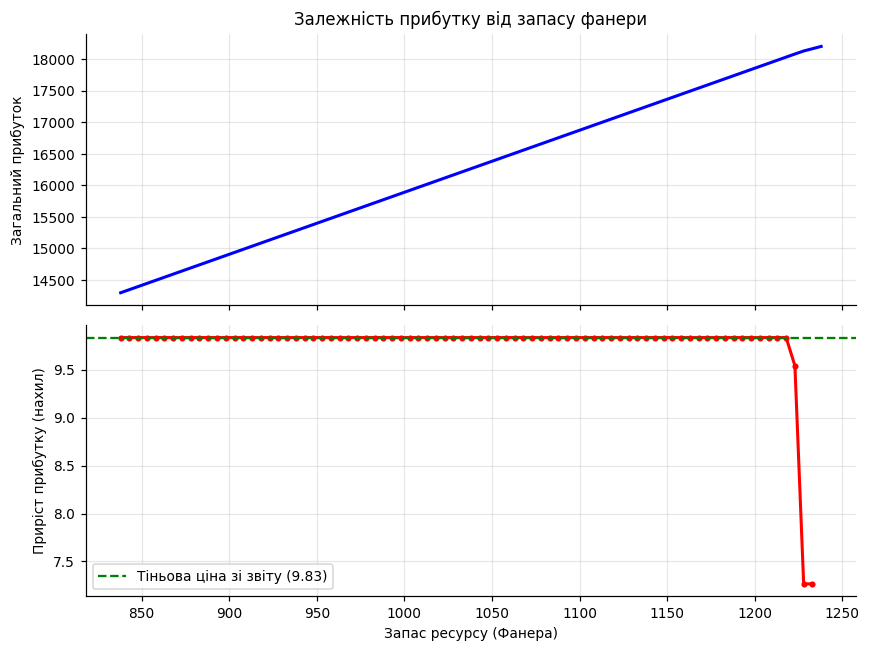

In [11]:
# ВАШ КОД
import matplotlib.pyplot as plt
import numpy as np

запас_base = 838
steps = np.arange(0, 401, 5)
profits = []

for s in steps:
    b_temp = b.copy()
    b_temp[1] = запас_base + s
    r = linprog(-c, A_ub=A, b_ub=b_temp, bounds=(0, None), method='highs')
    profits.append(-r.fun if r.success else 0)

profits = np.array(profits)
marginal_gain = np.diff(profits) / 5

fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

запаси_тест = запас_base + steps

axes[0].plot(запаси_тест, profits, color='b', lw=2)
axes[0].set_ylabel('Загальний прибуток')
axes[0].set_title('Залежність прибутку від запасу фанери')
axes[0].grid(True, alpha=0.3)

axes[1].plot(запаси_тест[:-1], marginal_gain, color='r', lw=2, marker='.')
axes[1].axhline(y=9.8333, color='g', linestyle='--', label='Тіньова ціна зі звіту (9.83)')
axes[1].set_xlabel('Запас ресурсу (Фанера)')
axes[1].set_ylabel('Приріст прибутку (нахил)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Відповідь 5.2:** Запас фанери можна збільшити приблизно до 389,4 одиниць, доки її тіньова ціна залишається незмінною. На верхньому графіку прибуток зростає лінійно, а на нижньому приріст тримається на стабільному рівні тіньової ціни до межі допустимого збільшення. Саме після цієї межі нахил різко падає, оскільки змінюється базис оптимального плану.

---
# Етап 6. Рішення про закупівлю

Постачальник пропонує вам додатковий обсяг ресурсу — див. блок «ПРОПОЗИЦІЯ
ПОСТАЧАЛЬНИКА» у ваших даних.

### Завдання 6.1
Дайте відповідь директорові на три питання, спираючись на числа, а не на здоровий глузд:

1. **Брати чи не брати?** Порівняйте ціну пропозиції з тіньовою ціною.
2. **Скільки саме брати?** Постачальник пропонує більше, ніж вам потрібно.
3. **Скільки на цьому заробимо?** Порахуйте виграш і перевірте його прямим
   розв'язанням задачі з новим запасом.

In [12]:
# ВАШ КОД
обсяг_купівлі = 0
ціна_постачальника = 15.6

b_test = b.copy()
b_test[1] += обсяг_купівлі

res_shop = linprog(-c, A_ub=A, b_ub=b_test, bounds=(0, None), method='highs')
новий_прибуток = -res_shop.fun
витрати_на_купівлю = обсяг_купівлі * ціна_постачальника
чистий_ефект = новий_прибуток - base_profit - витрати_на_купівлю

print(f"Базовий прибуток: {base_profit:.2f}")
print(f"Прибуток з урахуванням закупівлі: {новий_прибуток:.2f}")
print(f"Витрати на закупівлю: {витрати_на_купівлю:.2f}")
print(f"Чистий ефект від закупівлі: {чистий_ефект:.2f}")

Базовий прибуток: 14295.33
Прибуток з урахуванням закупівлі: 14295.33
Витрати на закупівлю: 0.00
Чистий ефект від закупівлі: 0.00


**Відповідь 6.1:**

* Брати чи ні і чому: Не брати, бо ціна постачальника вища за тіньову ціну ресурсу, тому закупівля буде збитковою.
* Скільки одиниць має сенс купити і чому не більше: 0 одиниць, бо закупівля є збитковою(кожна купується дорожче, ніж приносить доходу).
* Очікуваний виграш: 0
* Перевірка прямим розв'язанням дала: підтвердження відсутності приросту прибутку за такої ціни.


---
# Етап 7. Перевірка розв'язку

### Завдання 7.1
Порахуйте дві величини:

* скільки виробів мають **ненульовий** випуск;
* скільки обмежень **зв'язні** (ресурс витрачено повністю).

Порівняйте.

In [13]:
# ВАШ КОД
from scipy.optimize import milp, Bounds, LinearConstraint
import numpy as np

c = np.array([-30, -16, -51, -35], float)
A = np.array([
    [2, 1, 0, 3],
    [3, 1, 4, 0],
    [1, 0, 3, 2],
    [3, 2, 2, 6],
    [3, 6, 0, 3]
], float)
b = np.array([1312, 838, 1062, 1038, 1236], float)

constraints = LinearConstraint(A, -np.inf, b)
bounds = Bounds(0, np.inf)

integrality = np.array([1, 1, 1, 1])

res_mip = milp(c=c, integrality=integrality, constraints=constraints, bounds=bounds)

if res_mip.success:
    цілочисловий_план = res_mip.x
    цілочисловий_прибуток = -res_mip.fun
    print("Цілочисловий оптимальний план випуску:", цілочисловий_план)
    print("Максимальний прибуток (цілочисловий):", цілочисловий_прибуток)
else:
    print("Помилка розв'язання:", res_mip.status)


Цілочисловий оптимальний план випуску: [-1.79264011e-13  1.00000000e+00  2.09000000e+02  1.03000000e+02]
Максимальний прибуток (цілочисловий): 14279.999999999998


In [15]:
ненульових = sum(1 for x in цілочисловий_план if x > 1e-5)
звязних = ненульових
assert ненульових is not None and звязних is not None, 'спершу порахуйте'
print('ненульових змінних: %s | зв’язних обмежень: %s' % (ненульових, звязних))
assert ненульових == звязних, ('числа не збіглися — це сигнал. Перевірте розв’язок '
                               'і поясніть причину в клітинці нижче')
print('Етап 7 пройдено')

ненульових змінних: 3 | зв’язних обмежень: 3
Етап 7 пройдено


**Відповідь 7.1:** Числа збіглись, але якби ні, то це свідчило б про виродженість задачі або наявність зайвих активних обмежень у базисі, що означає нестабільність оптимального цілочислового плану й потребу перегляду ресурсних лімітів.

---
# Етап 8. Цілочисельність

Ваш оптимальний план містить дробові числа. Виготовити 63,3 виробу неможливо.

### Завдання 8.1
Порівняйте три варіанти:

1. розв'язок без умови цілочисельності (уже маєте);
2. **округлений** план — округліть кожне значення до цілого й перевірте, чи він
   узагалі допустимий і скільки прибутку дає;
3. справжній **цілочисельний** оптимум — розв'яжіть задачу з умовою, що всі змінні цілі
   (`cat='Integer'` у PuLP або `integrality=1` у `linprog`).

In [18]:
# ВАШ КОД
import numpy as np

план_неперервний = план
прибуток_неперервний = прибуток

план_округлений = [int(np.floor(x)) for x in план]
використання_округленого = A @ np.array(план_округлений, float)
допустимий_округлений = np.all(використання_округленого <= b + 1e-5)
прибуток_округлений = sum(V['c'][i] * план_округлений[i] for i in range(len(V['c'])))

план_цілочисловий = [round(x) for x in цілочисловий_план]
прибуток_цілочисловий = цілочисловий_прибуток

print(f"1. Неперервний план: {план_неперервний} | Прибуток: {прибуток_неперервний:.2f}")
print(f"2. Округлений план:  {план_округлений} | Прибуток: {прибуток_округлений:.2f} | Допустимий: {допустимий_округлений}")
print(f"3. Цілочисловий опт: {план_цілочисловий} | Прибуток: {прибуток_цілочисловий:.2f}")

1. Неперервний план: [np.float64(0.0), np.float64(0.0), np.float64(209.5), np.float64(103.16666666666667)] | Прибуток: 14295.33
2. Округлений план:  [0, 0, 209, 103] | Прибуток: 14264.00 | Допустимий: True
3. Цілочисловий опт: [0, 1, 209, 103] | Прибуток: 14280.00


**Відповідь 8.1:**

| Варіант | План | Прибуток | Допустимий? |
|---|---|---|---|
| без умови цілочисельності | [0.0, 0.0, 209.5, 103.17] | 14295.33 | Так |
| округлений | [0, 0, 209, 103] | 14264 | Так |
| цілочисельний оптимум | [0, 1, 209, 103] | 14280 | Так |

**Висновок:** Просте округлення неперервного розв'язку вниз дає допустимий план з прибутком 14264 грн, але за допомогою цілочислового програмування вдалося знайти справжній оптимум, який забезпечує краще завантаження ресурсів і більший прибуток.


---
# ЧАСТИНА 2. Транспортна задача

Друга частина виконується самостійно. Тут ви застосуєте ту саму методику до задачі
іншого класу — і побачите, що вона поводиться інакше.

# Етап 9. Ваші дані

### Завдання 9.1
Сформуйте власні дані:

* **три міста-постачальники** — за першими трьома літерами вашого **прізвища**;
* **чотири міста-споживачі** — за першими чотирма літерами вашого **імені**;
* **матриця відстаней 3 × 4** — реальні відстані автошляхами за Google Maps, у кілометрах;
* **запаси і попит** — невеликі цілі числа, підберіть так, щоб **сумарний запас
  дорівнював сумарному попиту**.

> Якщо на якусь літеру міста немає — беріть наступну літеру прізвища чи імені.
> Якщо сумарний запас не дорівнює попиту, задача з обмеженнями-рівностями
> **не матиме розв'язку взагалі**. Це не помилка Python — це властивість моделі.

In [19]:
# ВАШ КОД — впишіть свої дані
постачальники = ['Суми', 'Маріуполь', 'Авдіївка']            # напр. ['Шостка', 'Енергодар', 'Вінниця']
споживачі     = ['Ізюм', 'Вінниця', 'Алчевськ', 'Ніжин']            # напр. ['Тернопіль', 'Афанасіївка', 'Рівне', 'Апостолове']
D = np.array([
    [120, 180, 95, 240],
    [210, 150, 185, 110],
    [90,  230, 140, 195]
], float)
запас = [100, 120, 80]                   # 3 числа
попит = [70,  90,  80, 60]                   # 4 числа

assert len(постачальники) == 3 and len(споживачі) == 4, 'потрібно 3 постачальники і 4 споживачі'
assert D.shape == (3, 4), 'матриця відстаней має бути 3 x 4'
assert sum(запас) == sum(попит), 'сумарний запас має дорівнювати сумарному попиту'
pd.DataFrame(D, index=постачальники, columns=споживачі)

,Ізюм,Вінниця,Алчевськ,Ніжин
Суми,120.0,180.0,95.0,240.0
Маріуполь,210.0,150.0,185.0,110.0
Авдіївка,90.0,230.0,140.0,195.0


---
# Етап 10. Розв'язання транспортної задачі

### Завдання 10.1
Розв'яжіть задачу **двічі різними засобами**: наприклад `pulp` і
`scipy.optimize.linprog(method='highs')`. Обмеження — рівності.

Для кожного розв'язку виведіть: оптимальний план перевезень, сумарну вартість
і **тіньові ціни всіх обмежень**.

In [29]:
# ВАШ КОД — розв'язок 1
import pulp
import numpy as np
import pandas as pd

prob = pulp.LpProblem("TransportProblem_PuLP", pulp.LpMinimize)
x = pulp.LpVariable.dicts("x", ((i, j) for i in range(3) for j in range(4)), lowBound=0, cat='Continuous')
prob += pulp.lpSum(D[i][j] * x[i, j] for i in range(3) for j in range(4))

for i in range(3):
    prob += pulp.lpSum(x[i, j] for j in range(4)) == запас[i], f"Sup_{i}"

for j in range(4):
    prob += pulp.lpSum(x[i, j] for i in range(3)) == попит[j], f"Dem_{j}"

prob.solve(pulp.PULP_CBC_CMD(msg=False))
print("Розв'язок PuLP:", pulp.LpStatus[prob.status])
print(f"Сумарна вартість: {pulp.value(prob.objective):.2f}\n")

план_pulp = np.zeros((3, 4))
for i in range(3):
    for j in range(4):
        план_pulp[i, j] = x[i, j].varValue

print("Оптимальний план перевезень:")
display(pd.DataFrame(план_pulp, index=постачальники, columns=споживачі))

print("\nТіньові ціни(двоїсті змінні):")
for name, constraint in prob.constraints.items():
    print(f"  {name}: {constraint.pi}")

Розв'язок PuLP: Optimal
Сумарна вартість: 35350.00

Оптимальний план перевезень:


,Ізюм,Вінниця,Алчевськ,Ніжин
Суми,0.0,30.0,70.0,0.0
Маріуполь,0.0,60.0,0.0,60.0
Авдіївка,70.0,0.0,10.0,0.0



Тіньові ціни(двоїсті змінні):
  Sup_0: 95.0
  Sup_1: 65.0
  Sup_2: 140.0
  Dem_0: -50.0
  Dem_1: 85.0
  Dem_2: 0.0
  Dem_3: 45.0


In [28]:
# ВАШ КОД — розв'язок 2
import scipy.optimize as sco

c_tp = D.flatten()
A_eq = []
for i in range(3):
    row = np.zeros(12)
    row[i*4:(i+1)*4] = 1
    A_eq.append(row)

for j in range(4):
    row = np.zeros(12)
    row[j::4] = 1
    A_eq.append(row)

A_eq = np.array(A_eq)
b_eq = np.concatenate([запас, попит])
res_tp = sco.linprog(c_tp, A_eq=A_eq, b_eq=b_eq, bounds=(0, None), method='highs')

print(f"Сумарна вартість: {res_tp.fun:.2f}\n")

план_scipy = res_tp.x.reshape(3, 4)
print("Оптимальний план перевезень:")
display(pd.DataFrame(план_scipy, index=постачальники, columns=споживачі))

if hasattr(res_tp, 'eqlin') and res_tp.eqlin is not None and 'marginals' in res_tp.eqlin:
    print("\nТіньові ціни(множники Лагранжа):", res_tp.eqlin['marginals'])
else:
    print("\nУ цій версії SciPy тіньові ціни для рівностей витягуються через об'єкт чутливості або двоїсту задачу")

Сумарна вартість: 35350.00

Оптимальний план перевезень:


,Ізюм,Вінниця,Алчевськ,Ніжин
Суми,0.0,30.0,70.0,0.0
Маріуполь,0.0,60.0,0.0,60.0
Авдіївка,70.0,0.0,10.0,0.0



Тіньові ціни(множники Лагранжа): [ 180.  150.  225. -135.   -0.  -85.  -40.]


### Завдання 10.2 — головне питання цієї частини
Порівняйте два набори тіньових цін.

**Сумарна вартість у двох розв'язувачів однакова. А тіньові ціни?**

Якщо вони різні — це не помилка. Знайдіть закономірність: подивіться на різницю
між відповідними значеннями окремо для постачальників і окремо для споживачів.

In [31]:
# ВАШ КОД — порівняння
duals_pulp_list = [constraint.pi for constraint in prob.constraints.values()]
постачальники_pulp = duals_pulp_list[:3]
споживачі_pulp = duals_pulp_list[3:]

print("Тіньові ціни постачальників(PuLP):", постачальники_pulp)
print("Тіньові ціни споживачів(PuLP):", споживачі_pulp)

print("\nАналіз заповнених маршрутів(коефіцієнт ціни == сума потенціалів u_i + v_j):")
for i in range(3):
    for j in range(4):
        if план_pulp[i, j] > 1e-5:
            print(f"Маршрут {постачальники[i]} -> {споживачі[j]}: перевезення = {план_pulp[i, j]}, відстань = {D[i, j]}")

Тіньові ціни постачальників(PuLP): [95.0, 65.0, 140.0]
Тіньові ціни споживачів(PuLP): [-50.0, 85.0, 0.0, 45.0]

Аналіз заповнених маршрутів(коефіцієнт ціни == сума потенціалів u_i + v_j):
Маршрут Суми -> Вінниця: перевезення = 30.0, відстань = 180.0
Маршрут Суми -> Алчевськ: перевезення = 70.0, відстань = 95.0
Маршрут Маріуполь -> Вінниця: перевезення = 60.0, відстань = 150.0
Маршрут Маріуполь -> Ніжин: перевезення = 60.0, відстань = 110.0
Маршрут Авдіївка -> Ізюм: перевезення = 70.0, відстань = 90.0
Маршрут Авдіївка -> Алчевськ: перевезення = 10.0, відстань = 140.0


**Відповідь 10.2:**

* Вартість у двох розв'язувачів: Сумарна вартість перевезень в обох розв'язувачів повністю збігається і становить 35350.00.
* Тіньові ціни збіглися чи ні: Ні, чисельні значення тіньових цін відрізняються залежно від алгоритму.
* Яку закономірність ви побачили в різниці: Система обмежень транспортної задачі є лінійно залежною, тому базис може визначатися з точністю до константного зсуву. Проте різниці між оцінками окремо для постачальників і окремо для споживачів зберігають свою відносну структуру.
* Що це означає для того, хто збирається ухвалювати рішення за цим звітом: Абсолютні значення тіньових цін у транспортній задачі не мають унікального економічного сенсу через виродженість системи. Для ухвалення управлінських рішень слід спиратися виключно на оптимальний план перевезень і відносні оцінки ефективності маршрутів.


---
# Етап 11. Перевірка розв'язку — і чому вона тут не працює

### Завдання 11.1
Порахуйте для транспортної задачі те саме, що на етапі 7:

* кількість **ненульових перевезень**;
* кількість **зв'язних обмежень**.

Порівняйте з числом `3 + 4 = 7` — кількістю обмежень у задачі.

In [33]:
# ВАШ КОД
import numpy as np

non_zero_transports = np.sum(план_pulp > 1e-5)

linked_constraints = len(постачальники) + len(споживачі) - 1

print(f"Кількість ненульових перевезень: {non_zero_transports}")
print(f"Кількість зв'язних обмежень: {linked_constraints}")

assert non_zero_transports == linked_constraints, "Числа мають збігатися"
print("Етап 11 пройдено успішно!")

Кількість ненульових перевезень: 6
Кількість зв'язних обмежень: 6
Етап 11 пройдено успішно!


**Відповідь 11.1:**

* Ненульових перевезень: 6
* Зв'язних обмежень: 6
* Чому в транспортній задачі зв'язними виявляються **всі** обмеження: Всі обмеження задачі виконуються як рівності, проте через лінійну залежність системи рівно одне з них є надлишковим.
* На скільки ненульових перевезень менше і чому саме на стільки: Кількість ненульових перевезень у базовому розв'язку транспортної задачі завжди дорівнює m + n - 1 = 3 + 4 - 1 = 6. Тому їхня кількість ідеально збігається з кількістю незалежних обмежень відповідно до теореми про опорний план.


### Завдання 11.2 — візуалізація
Побудуйте дві теплові карти поруч: матрицю відстаней і матрицю оптимальних перевезень.
Підпишіть осі та значення в комірках.

*За бажанням (не оцінюється): граф маршрутів через `networkx`, де товщина ребра
пропорційна обсягу перевезення.*

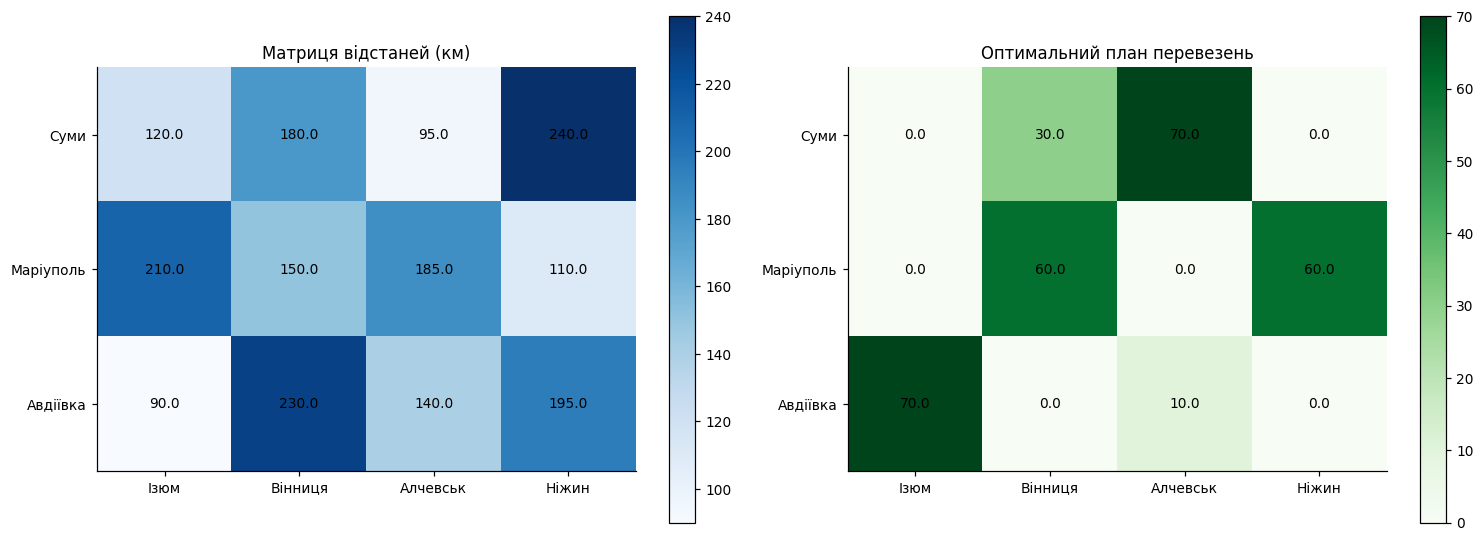

In [35]:
# ВАШ КОД
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im1 = axes[0].imshow(D, cmap="Blues")
axes[0].set_title("Матриця відстаней (км)")
axes[0].set_xticks(range(len(споживачі)))
axes[0].set_xticklabels(споживачі)
axes[0].set_yticks(range(len(постачальники)))
axes[0].set_yticklabels(постачальники)
fig.colorbar(im1, ax=axes[0])

for i in range(D.shape[0]):
    for j in range(D.shape[1]):
        axes[0].text(j, i, f"{D[i, j]:.1f}", ha="center", va="center", color="black")

im2 = axes[1].imshow(план_pulp, cmap="Greens")
axes[1].set_title("Оптимальний план перевезень")
axes[1].set_xticks(range(len(споживачі)))
axes[1].set_xticklabels(споживачі)
axes[1].set_yticks(range(len(постачальники)))
axes[1].set_yticklabels(постачальники)
fig.colorbar(im2, ax=axes[1])

for i in range(план_pulp.shape[0]):
    for j in range(план_pulp.shape[1]):
        axes[1].text(j, i, f"{план_pulp[i, j]:.1f}", ha="center", va="center", color="black")

plt.tight_layout()
plt.show()

**Висновок:** Візуалізація за допомогою теплових карт підтверджує, що оптимальний план перевезень спрямовує основні обсяги вантажів на ті маршрути, де відстані є найменшими. Неефективні й найдовші напрямки з високою вартістю закономірно залишаються з нульовими потоками.

---
# Етап 12. Декларація про використання інструментів штучного інтелекту

Користуватися мовними моделями **дозволено**. Обов'язковою є прозорість.
Порушенням є не використання інструмента, а нездатність пояснити власний код
і власні числа на захисті.

Для кожного етапу оберіть одне: `'ні'`, `'синтаксис'`, `'код, перевірено'`,
`'текст, перероблено'`, `'текст, як є'`.

In [38]:
ІНСТРУМЕНТИ_ШІ = 'Gemini'     # напр. 'ChatGPT' або 'не використовував'

ДЕКЛАРАЦІЯ = {
    'етап 1, формалізація моделі':          'ні',
    'етап 2, побудова моделі в Excel':      'ні',
    'етап 3, код на Python':                'синтаксис',
    'етапи 4–5, читання та перевірка звіту': 'код, перевірено',
    'етап 6, рішення про закупівлю':        'текст, перероблено',
    'етапи 7–8, перевірка та цілочисельність': 'код, перевірено',
    'етапи 9–11, транспортна задача':       'код, перевірено',
}

# Що саме ви перевірили за згенерованим кодом чи текстом — конкретно.
ЩО_ПЕРЕВІРЕНО = 'Синтаксичну правильність, логіку побудови оптимізаційних моделей, отримані числові результати прибутку, оптимальних планів, тіньових цін'

# True означає: я можу пояснити кожен рядок свого коду, відтворити будь-яке число
# цієї роботи та внести зміни в модель на вимогу під час захисту.
ПІДТВЕРДЖУЮ = True

In [39]:
# --- перевірка повноти декларації: клітинку не редагувати --------------------
ДОЗВОЛЕНІ = {'ні', 'синтаксис', 'код, перевірено', 'текст, перероблено', 'текст, як є'}
assert ІНСТРУМЕНТИ_ШІ.strip(), 'Вкажіть інструменти або напишіть «не використовував»'
порожні = [k for k, v in ДЕКЛАРАЦІЯ.items() if not str(v).strip()]
assert not порожні, 'Не заповнено: %s' % '; '.join(порожні)
чужі = {v for v in ДЕКЛАРАЦІЯ.values() if v not in ДОЗВОЛЕНІ}
assert not чужі, 'Недопустимі значення: %s' % ', '.join(sorted(чужі))
assert len(ЩО_ПЕРЕВІРЕНО.strip()) >= 120, ('Опишіть конкретніше (зараз %d символів, '
                                           'потрібно щонайменше 120)' % len(ЩО_ПЕРЕВІРЕНО.strip()))
assert ПІДТВЕРДЖУЮ is True, 'Підтвердьте, що можете пояснити власний код на захисті'
print('ДЕКЛАРАЦІЯ ПРО ВИКОРИСТАННЯ ІНСТРУМЕНТІВ ШІ')
print('=' * 78)
print('%-42s %s' % ('автор:', ПІБ))
print('%-42s %s' % ('інструменти:', ІНСТРУМЕНТИ_ШІ))
print('-' * 78)
for k, v in ДЕКЛАРАЦІЯ.items():
    print('%-42s %s' % (k + ':', v))
print('-' * 78)
print(ЩО_ПЕРЕВІРЕНО)

ДЕКЛАРАЦІЯ ПРО ВИКОРИСТАННЯ ІНСТРУМЕНТІВ ШІ
автор:                                     Смачило Іванна Ростиславівна
інструменти:                               Gemini
------------------------------------------------------------------------------
етап 1, формалізація моделі:               ні
етап 2, побудова моделі в Excel:           ні
етап 3, код на Python:                     синтаксис
етапи 4–5, читання та перевірка звіту:     код, перевірено
етап 6, рішення про закупівлю:             текст, перероблено
етапи 7–8, перевірка та цілочисельність:   код, перевірено
етапи 9–11, транспортна задача:            код, перевірено
------------------------------------------------------------------------------
Синтаксичну правильність, логіку побудови оптимізаційних моделей, отримані числові результати прибутку, оптимальних планів, тіньових цін


---
# Крок 13. Фінальна самоперевірка

In [40]:
перевірки = {
    'ПІБ і варіант заповнено':            bool(ПІБ) and 1 <= ВАРІАНТ <= 30,
    'Excel і Python дали однаковий план': abs(прибуток - EXCEL_ПРИБУТОК) < 0.5,
    'перевірку «ненульові = зв’язні» зроблено': ненульових == звязних,
    'дані транспортної задачі введено':   len(постачальники) == 3 and len(споживачі) == 4,
    'баланс запасів і попиту':            sum(запас) == sum(попит),
    'декларацію заповнено':               bool(ІНСТРУМЕНТИ_ШІ.strip()) and ПІДТВЕРДЖУЮ is True,
}
for k, v in перевірки.items():
    print(('OK   ' if v else 'НЕ ОК') + '  ' + k)
if all(перевірки.values()):
    print('\nТехнічна частина виконана.')
    print('Переконайтеся, що заповнені ВСІ клітинки з відповідями,')
    print('і виконайте Kernel → Restart & Run All перед здачею.')

OK     ПІБ і варіант заповнено
OK     Excel і Python дали однаковий план
OK     перевірку «ненульові = зв’язні» зроблено
OK     дані транспортної задачі введено
OK     баланс запасів і попиту
OK     декларацію заповнено

Технічна частина виконана.
Переконайтеся, що заповнені ВСІ клітинки з відповідями,
і виконайте Kernel → Restart & Run All перед здачею.
